In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [6]:
df = pd.read_csv("/content/sample_data/california_housing_train.csv")

In [7]:
print("Initial Data Overview")
print(df.info())

Initial Data Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB
None


In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


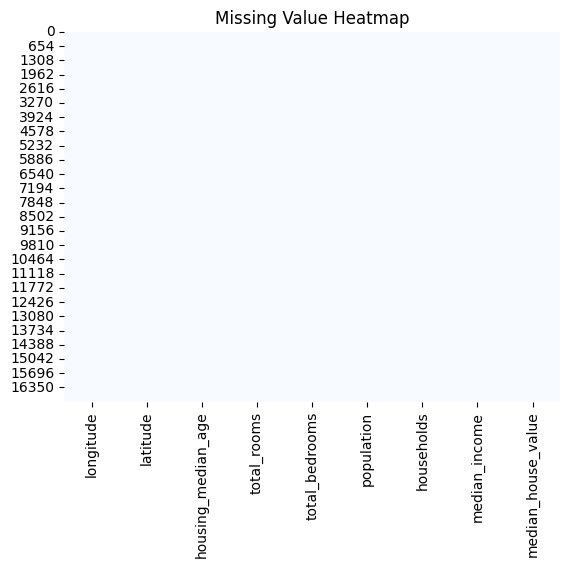

In [9]:
sns.heatmap(df.isnull(), cbar=False, cmap="Blues")
plt.title("Missing Value Heatmap")
plt.show()

In [11]:
# Clean columns only if they exist in the current DataFrame
loan_categorical = ["Gender", "Married", "Dependents", "Self_Employed"]
for col in loan_categorical:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

if "LoanAmount" in df.columns:
    df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

for col in ["Loan_Amount_Term", "Credit_History"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicates
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print("Duplicates Removed:", initial_rows - len(df))

Duplicates Removed: 0


In [13]:
# Clean columns if they exist in the current DataFrame
if "Dependents" in df.columns:
    df["Dependents"] = df["Dependents"].replace("3+", 3).astype(int)

for col in ["Gender", "Married", "Education", "Self_Employed", "Property_Area"]:
    if col in df.columns:
        df[col] = df[col].str.strip().str.capitalize()

loan_numeric = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]
if all(col in df.columns for col in loan_numeric):
    minmax = MinMaxScaler()
    df[loan_numeric] = minmax.fit_transform(df[loan_numeric])

if "Credit_History" in df.columns:
    standard = StandardScaler()
    df[["Credit_History"]] = standard.fit_transform(df[["Credit_History"]])

print("\nCleaned Data Overview")
print(df.info())
print(df.head())


Cleaned Data Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB
None
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0     